# Netflix Global Content Strategy Analysis


**Author:** Sai Sujay

**Tools:** Python, Pandas, NumPy, Matplotlib, Jupyter Notebook

**Project Type:** Business & Data Analytics
## Project Overview

### Business Problem
Netflix has a vast global content library, but understanding how that catalog is distributed and has evolved over time is essential for making informed content strategy decisions. This project analyzes Netflix's catalog to identify patterns in geographic distribution, content growth, audience segmentation, and genre diversity that can support strategic planning.

### Why This Analysis Matters
A well-balanced content portfolio helps organizations identify opportunities, reduce concentration risks, and better understand long-term content trends. Although this dataset does not include financial or engagement metrics, it provides valuable insights that can guide further business investigation and support evidence-based decision-making.

## Business Problem

Netflix's Content Strategy team wants to gain a better understanding of its global content library. By analyzing the geographic distribution of titles, the balance between Movies and TV Shows, and content growth over time, the goal is to identify opportunities for future content investment and support strategic decision-making.

## Table of Contents

1. Business Context
2. Data Understanding
3. Data Quality Assessment
4. Cleaning Strategy
5. Portfolio Concentration Analysis
6. Growth Trend Analysis
7. Content Strategy Analysis
8. Audience & Genre Strategy
9. Executive Conclusion

## Business Objectives

- Analyze the geographic distribution of Netflix content across different countries.
- Evaluate the balance between Movies and TV Shows in the content catalog.
- Identify content growth trends across countries and over time.
- Generate data-driven insights to support future content investment and diversification strategies.

## Dataset Limitations

This dataset contains information about Netflix's content catalog but does **not** include key business metrics such as:

- Revenue generated by each title
- Watch time
- Subscriber engagement
- Production or licensing costs

Therefore, all insights and recommendations in this analysis are based solely on the characteristics of the available content catalog and should not be interpreted as measures of business or financial performance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
net=pd.read_csv('netflix_titles.csv')

In [170]:
df=net.copy()

> **Note:** Before starting the analysis, a copy of the original dataset is created. This provides a backup of the raw data, allowing data cleaning and transformations to be performed safely without permanently altering the original dataset.

Data Audit:
-

In [7]:
df.shape

(8807, 12)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [4]:
df.describe(include='all')

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


In [45]:
df['show_id'] = df['show_id'].str.strip().str.lower()
df['show_id'].is_unique

True

## Data Audit Report:

- **Total Rows:** 8,807
- **Total Columns:** 12

### Data Types

- 11 columns have the **object** data type.
- 1 column (`release_year`) has the **int64** data type.

### Unique Identifier

- `show_id` is the unique identifier.
- No duplicate `show_id` values were found.

### Numerical Column

- `release_year`
  - Although stored as an integer, it is best interpreted as a **time variable** rather than a continuous numerical variable.

### Categorical Columns

- `type`
- `country`
- `rating`
- `listed_in`
- `duration`

### Text Columns

- `title`
- `director`
- `cast`
- `description`

### Date Column

- `date_added`

Data Quality:
-

In [46]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [100]:
df.sample(8)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8289,s8290,Movie,The Endless,"Justin Benson, Aaron Moorhead","Aaron Moorhead, Justin Benson, Callie Hernande...",United States,"September 19, 2018",2017,TV-MA,112 min,"Independent Movies, Sci-Fi & Fantasy, Thrillers","As kids, they escaped a UFO death cult. Now, t..."
1678,s1679,Movie,Raman Raghav 2.0,Anurag Kashyap,"Nawazuddin Siddiqui, Vicky Kaushal, Sobhita Dh...",India,"November 19, 2020",2016,TV-MA,133 min,"International Movies, Thrillers",A corrupt cop and a serial killer obsessed wit...
1092,s1093,Movie,Dolly Parton: A MusiCares Tribute,NaN,Dolly Parton,NaN,"April 7, 2021",2021,TV-PG,55 min,"Documentaries, Music & Musicals",In a star-studded evening of music and memorie...
6518,s6519,Movie,Come and Find Me,Zack Whedon,"Aaron Paul, Annabelle Wallis, Garret Dillahunt...","Canada, United States, United Kingdom","September 18, 2019",2016,R,112 min,"Dramas, Thrillers","When his photographer girlfriend vanishes, an ..."
3799,s3800,TV Show,She's Gotta Have It,NaN,"DeWanda Wise, Cleo Anthony, Lyriq Bent, Anthon...",United States,"May 24, 2019",2018,TV-MA,2 Seasons,"Romantic TV Shows, TV Comedies, TV Dramas",Nola Darling struggles to stay true to herself...
4553,s4554,TV Show,Monty Python's Personal Best,NaN,"John Cleese, Terry Gilliam, Terry Jones, Graha...","United States, United Kingdom","October 2, 2018",2005,TV-MA,1 Season,"British TV Shows, TV Comedies",Original members of the iconic Monty Python co...
3247,s3248,TV Show,Trolls: The Beat Goes On!,NaN,"Amanda Leighton, Skylar Astin, Ron Funches, Da...",United States,"November 22, 2019",2019,TV-Y7,8 Seasons,"Kids' TV, TV Comedies",As Queen Poppy welcomes a new time of peace in...
353,s354,Movie,The Haunting in Connecticut 2: Ghosts of Georgia,Tom Elkins,"Abigail Spencer, Chad Michael Murray, Katee Sa...",United States,"August 1, 2021",2013,R,101 min,Horror Movies,A couple's Georgia dream home becomes a living...


## Data Quality Assessment:

| Column | Missing Values | Data Type | Quality Issue | Action Required |
|--------|---------------:|-----------|---------------|-----------------|
| country | 831 | object | Multiple countries in one cell | Split & Normalize, Missing country values reduce the accuracy of geographic analysis but do not affect analyses unrelated to country |
| director | 2634 | object | Missing values | Keep missing values (not required for current analysis) |
| cast | 825 | object | Missing values | Keep missing values (not required for current analysis) |
| date_added | 10 | object | Incorrect data type | Convert to datetime |
| rating | 4 | object | Missing values | Handle missing values |
| duration | 3 | object | Missing values | Handle missing values |

Duplicate Assessment:
-

-Inconsistent capitalization and leading/trailing spaces  Standardize text using `str.strip()` and `str.lower()` during duplicate checks  This ensures that duplicate detection is not affected by formatting differences while keeping the original dataset unchanged.

In [48]:
df[df['title'].str.strip().str.lower().duplicated(keep=False)].sort_values('title')

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
3371,s3372,Movie,Consequences,Ozan Açıktan,"Nehir Erdoğan, Tardu Flordun, İlker Kaleli, Se...",Turkey,"October 25, 2019",2014,TV-MA,106 min,"Dramas, International Movies, Thrillers",Secrets bubble to the surface after a sensual ...
6529,s6530,Movie,Consequences,Ozan Açıktan,"Nehir Erdoğan, Tardu Flordun, İlker Kaleli, Se...",Turkey,"October 25, 2019",2014,TV-MA,106 min,"Dramas, International Movies, Thrillers",Secrets bubble to the surface after a sensual ...
5751,s5752,TV Show,DEATH NOTE,NaN,"Kappei Yamaguchi, Alessandro Juliani, Mamoru M...",Japan,"October 15, 2016",2006,TV-14,1 Season,"Anime Series, Crime TV Shows, International TV...",When a Japanese high schooler comes into posse...
5318,s5319,Movie,Death Note,Adam Wingard,"Willem Dafoe, Nat Wolff, Lakeith Stanfield, Ma...",United States,"August 25, 2017",2017,TV-MA,100 min,"Horror Movies, Thrillers",Light Turner finds a supernatural notebook and...
6705,s6706,Movie,Esperando La Carroza,Alejandro Doria,"Luis Brandoni, China Zorrilla, Antonio Gasalla...",Argentina,"July 15, 2018",1985,NR,95 min,"Comedies, Cult Movies, International Movies",Cora has three sons and a daughter and she´s a...
303,s304,Movie,Esperando la carroza,Alejandro Doria,"Luis Brandoni, China Zorrilla, Antonio Gasalla...",Argentina,"August 5, 2021",1985,TV-MA,95 min,"Comedies, Cult Movies, International Movies",Cora has three sons and a daughter and she´s a...
5033,s5034,Movie,FullMetal Alchemist,Fumihiko Sori,"Ryosuke Yamada, Tsubasa Honda, Dean Fujioka, M...",Japan,"February 19, 2018",2017,TV-PG,134 min,"Action & Adventure, Dramas, International Movies",While alchemist Edward Elric searches for a wa...
5095,s5096,TV Show,Fullmetal Alchemist,NaN,"Romi Park, Rie Kugimiya, Megumi Toyoguchi, Miy...",Japan,"January 1, 2018",2003,TV-14,1 Season,"Anime Series, International TV Shows",Brothers Edward and Alphonse use alchemy to re...
7345,s7346,Movie,Love In A Puff,Pang Ho-cheung,"Miriam Chin Wah Yeung, Shawn Yue, Singh Hartih...",Hong Kong,"August 1, 2018",2010,TV-MA,103 min,"Comedies, Dramas, International Movies",When the Hong Kong government enacts a ban on ...
159,s160,Movie,Love in a Puff,Pang Ho-cheung,"Miriam Chin Wah Yeung, Shawn Yue, Singh Hartih...",Hong Kong,"September 1, 2021",2010,TV-MA,103 min,"Comedies, Dramas, International Movies",When the Hong Kong government enacts a ban on ...


> ***NOTE:***  Duplicate titles are expected because remakes or different productions may share the same title. Therefore title cannot be used as a unique identifier.

In [78]:
df.duplicated().sum()

np.int64(0)

In [79]:
df['show_id'].duplicated().sum()

np.int64(0)

## Duplicate Records Analysis

### How many duplicate rows?

- **Duplicate Rows Found:** **0**
- No completely identical rows were found in the dataset. Therefore, duplicate row removal is not required.

### Are duplicate `show_id` values present?

- **Duplicate `show_id` Values:** **0**
- The `show_id` column is unique for every record, confirming that it is a valid unique identifier.

### If duplicates exist, what will you do?

- If duplicate rows are identified, they should first be investigated to determine whether they are genuine duplicate records or intentional repeated entries.
- Exact duplicate records with no business significance should be removed using `drop_duplicates()` to prevent biased analysis.
- If duplicate `show_id` values are found, they indicate a data quality issue since `show_id` is the unique identifier. Such records should be investigated, and the incorrect duplicate should be removed or corrected.
- **Observation:** Duplicate values are expected in several columns, such as `country`, `type`, and `rating`, because multiple titles can share these attributes. Since the dataset contains no duplicate rows and `show_id` is unique for every record, no duplicate removal was required.

## Data Cleaning Strategy

| Issue                                                   | Solution                                                                       | Reason                                                                                                                                                                       |
| ------------------------------------------------------- | ------------------------------------------------------------------------------ | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Missing `country` values                                | Exclude records only when performing country-based analysis                    | Since the country information is unavailable, including these records in geographic analysis could lead to misleading conclusions. They are retained for all other analyses. |
| Multiple countries in a single cell (`country`)         | Split and explode the `country` column                                         | This allows each country to be counted individually, providing a more accurate view of Netflix's geographic content distribution.                                            |
| `date_added` stored as `object`                         | Convert to `datetime`                                                          | Converting this column makes it easier to analyze content additions over time, sort dates correctly, and extract features such as year and month.                            |
| Mixed values in `duration`                              | Treat Movie durations as minutes and TV Show durations as seasons              | Movies and TV Shows use different units of measurement, so they should be analyzed separately to avoid incorrect comparisons.                                                |
| Multiple genres in a single cell (`listed_in`)          | Split and explode the `listed_in` column                                       | This enables analysis of individual genres, helping identify the most common genres, genre distribution, and the diversity of Netflix's content catalog.                     |



Business Question:
-
***1.Is Netflix's content portfolio geographically concentrated?***


In [6]:
df['country'].value_counts()

country
United States                             2818
India                                      972
United Kingdom                             419
Japan                                      245
South Korea                                199
                                          ... 
Romania, Bulgaria, Hungary                   1
Uruguay, Guatemala                           1
France, Senegal, Belgium                     1
Mexico, United States, Spain, Colombia       1
United Arab Emirates, Jordan                 1
Name: count, Length: 748, dtype: int64

In [4]:
country_series = df['country'].dropna().str.split(',')
country_series = country_series.explode()
country_series=country_series.str.strip()

In [7]:
country_series.value_counts()

country
United States     3690
India             1046
United Kingdom     806
Canada             445
France             393
                  ... 
Ecuador              1
Armenia              1
Mongolia             1
Bahamas              1
Montenegro           1
Name: count, Length: 123, dtype: int64

> **Note:** Here we can see the change in count of each country after removing leading & trailing spaces and comparing all the rows in lower alphabets

Analysis Questions:
-

**1.Which are the Top 10 contributing countries?**

In [8]:
country_series.value_counts().head(10)

country
United States     3690
India             1046
United Kingdom     806
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64

**2.What percentage of the catalog comes from the Top 1 country?**

In [9]:
country_series.value_counts(normalize=True).head(1)*100

country
United States    36.830023
Name: proportion, dtype: float64

**3.What percentage comes from the Top 5 countries?**

In [12]:
country_series.value_counts(normalize=True).head(5)*100

country
United States     36.830023
India             10.440164
United Kingdom     8.044715
Canada             4.441561
France             3.922547
Name: proportion, dtype: float64

In [14]:
sum(country_series.value_counts(normalize=True).head(5)*100)

63.679009881225674

KPI:
-

In [5]:
total = country_series.nunique()

top_c = country_series.value_counts().index[0]

top_cp = country_series.value_counts(normalize=True).iloc[0] * 100

top_cp5 = country_series.value_counts(normalize=True).head().sum() * 100

rc = 100 - top_cp5

kpi = pd.DataFrame({
    'KPI': [
        'Total Countries',
        'Top Country',
        'Top Country Share',
        'Top 5 Countries Share',
        'Remaining Countries Share'
    ],
    'Value': [
        total,
        top_c,
        f'{top_cp:.2f}%',
        f'{top_cp5:.2f}%',
        f'{rc:.2f}%'
    ]
})

kpi

,KPI,Value
0,Total Countries,123
1,Top Country,United States
2,Top Country Share,36.83%
3,Top 5 Countries Share,63.68%
4,Remaining Countries Share,36.32%


Visualization:
-

In [6]:
top=country_series.value_counts().head(10)
top

country
United States     3690
India             1046
United Kingdom     806
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64

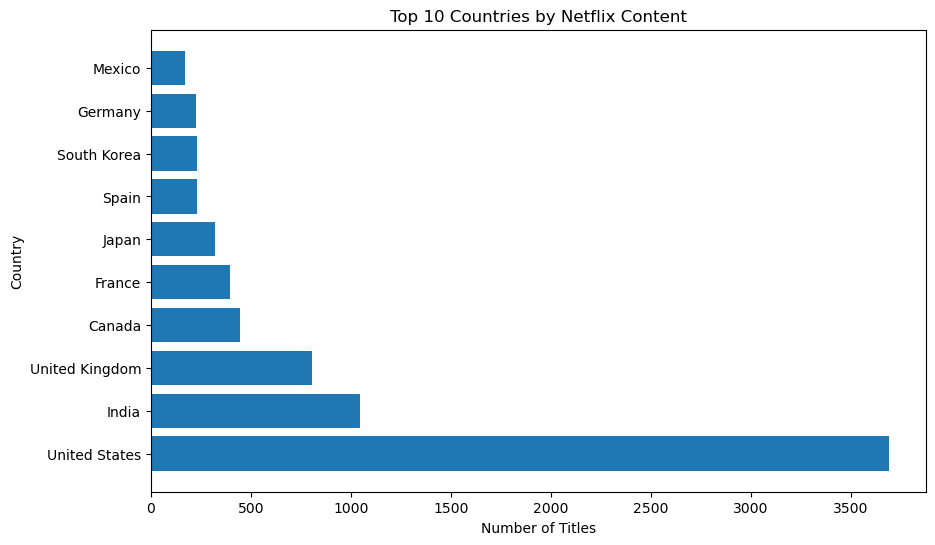

In [7]:
plt.figure(figsize=(10,6))
plt.barh(top.index,top.values)
plt.title('Top 10 Countries by Netflix Content')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.show()

## Observation

More than half (**63.68%**) of Netflix's catalog comes from just **five countries**. This indicates that the content library is concentrated in a relatively small number of content-producing markets, while many other countries have a much smaller representation.

---

## Business Insight

This concentration suggests that Netflix has historically focused its investments on a few major markets. Expanding content from underrepresented regions could improve catalog diversity, strengthen regional representation, and reduce dependence on a small number of countries.

---

## Recommendation

Based on the available catalog data, management should consider continuing investments in major content-producing countries while gradually increasing content acquisition and production in underrepresented regions. This could help create a more geographically balanced content library.

---

## Limitation

This analysis is based only on the number of titles in the catalog. Since the dataset does not include watch time, subscriber engagement, revenue, or production costs, it cannot determine which countries generate the highest business value.

---

## Confidence Level

**Confidence:** Medium

The catalog clearly shows a geographic concentration of content. However, additional business metrics would be needed to confidently recommend future investment decisions.

Business Question
-
***2.Which countries have experienced the strongest growth in content production over time, and what does that imply for Netflix's future content strategy?***

In [67]:
country_df = df.copy()

country_df = country_df.dropna(subset=['country'])

country_df['country'] = (
    country_df['country']
    .str.split(',')
)

country_df = country_df.explode('country')

country_df['country'] = country_df['country'].str.strip().str.lower()

In [68]:
country_df['country'].value_counts().head()

country
united states     3690
india             1046
united kingdom     806
canada             445
france             393
Name: count, dtype: int64

In [131]:
temp=country_df.groupby(['country', 'release_year'])['title'].count().reset_index()
temp

,country,release_year,title
0,,1975,1
1,,2014,2
2,,2018,2
3,,2020,1
4,,2021,1
...,...,...,...
1098,West Germany,1977,1
1099,West Germany,1985,1
1100,West Germany,1986,1
1101,Zimbabwe,2014,1


In [132]:
temp.loc[:5, 'country'].apply(repr)

0               ''
1               ''
2               ''
3               ''
4               ''
5    'Afghanistan'
Name: country, dtype: object

In [133]:
df.groupby(['country', 'release_year'])['title'].count().reset_index()

,country,release_year,title
0,", France, Algeria",2014,1
1,", South Korea",2021,1
2,Argentina,1985,2
3,Argentina,1998,1
4,Argentina,2004,1
...,...,...,...
1749,Vietnam,2019,2
1750,Vietnam,2020,1
1751,Vietnam,2021,1
1752,West Germany,1977,1


### Additional Data Quality Issue

While cleaning the `country` column, a few records were found to contain malformed values with a leading comma.

After splitting the `country` column on commas and exploding the resulting lists, these records generated empty string (`''`) values as separate rows.

To prevent blank countries from appearing in grouped analyses and visualizations, these empty string values were removed after exploding the column.

In [69]:
# Remove empty strings created from malformed country values (e.g. ", South Korea")
country_df = country_df[country_df['country'] != '']

In [70]:
country_df.groupby(['country', 'release_year'])['title'].count().reset_index()

,country,release_year,title
0,afghanistan,2016,1
1,albania,2018,1
2,algeria,1979,1
3,algeria,2014,1
4,algeria,2020,1
...,...,...,...
1093,west germany,1977,1
1094,west germany,1985,1
1095,west germany,1986,1
1096,zimbabwe,2014,1


In [71]:
top5_countries = country_df['country'].value_counts().head(5).index

In [72]:
top5_df = country_df[country_df['country'].isin(top5_countries)]

In [73]:
country_year = (
    top5_df
    .groupby(['country', 'release_year'])['title']
    .count()
    .reset_index(name='title_count')
)

country_year_pivot = (
    country_year
    .pivot(
        index='release_year',
        columns='country',
        values='title_count'
    )
    .fillna(0)
)

country_year_pivot

country,canada,france,india,united kingdom,united states
release_year,,,,,
1942,0.0,0.0,0.0,0.0,2.0
1943,0.0,0.0,0.0,0.0,3.0
1944,0.0,0.0,0.0,1.0,3.0
1945,0.0,0.0,0.0,0.0,4.0
1946,0.0,0.0,0.0,0.0,2.0
...,...,...,...,...,...
2017,58.0,40.0,111.0,101.0,442.0
2018,67.0,47.0,101.0,96.0,457.0
2019,44.0,49.0,93.0,68.0,428.0


Visualisation:
-

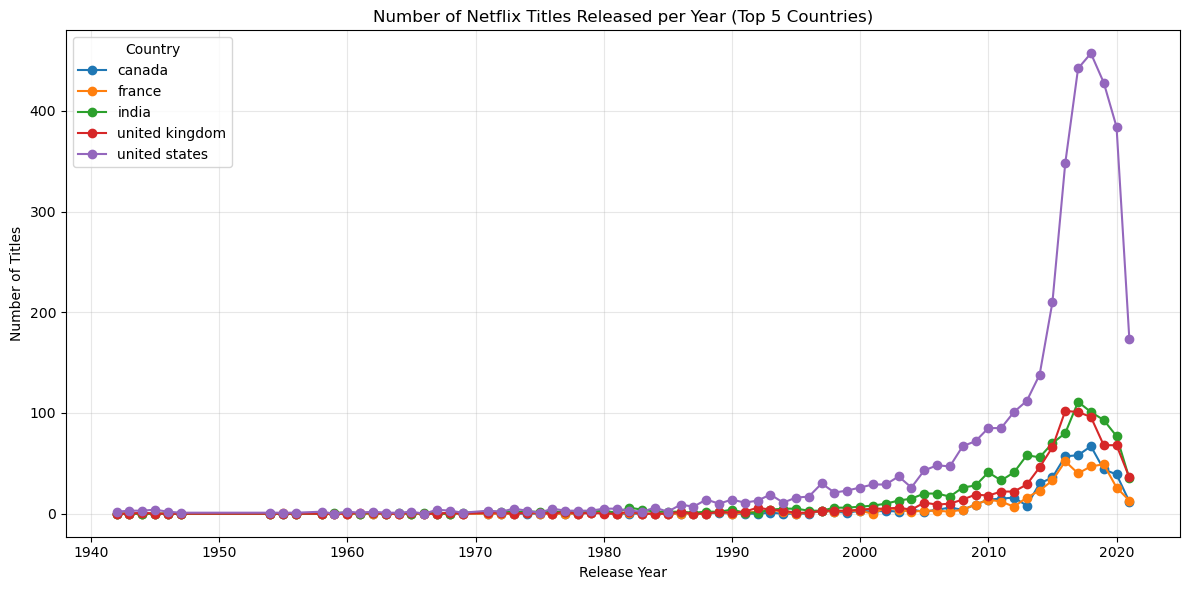

In [74]:
plt.figure(figsize=(12,6))

for country in country_year_pivot.columns:
    plt.plot(
        country_year_pivot.index,
        country_year_pivot[country],
        marker='o',
        label=country
    )

plt.title('Number of Netflix Titles Released per Year (Top 5 Countries)')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.legend(title='Country')
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

## Trend Analysis

### Countries Showing Consistent Growth

- **United States** demonstrates the strongest and most consistent growth, particularly after 2005, before declining in the most recent years.
- **India** shows steady growth throughout the 2000s and 2010s, making it the second-fastest growing country among the top five.

---

### Countries Showing Moderate Growth

- **United Kingdom** exhibits gradual growth with a noticeable acceleration after 2015 before experiencing a decline.
- **Canada** and **France** display slower but steady growth with relatively minor year-to-year fluctuations.

---

### Countries Showing Decline or Stagnation

- **Canada** and **France** remain largely stagnant during the earlier years before their catalogs begin expanding after 2010.
- All five countries show a decline in the most recent years of the dataset. However, this should be interpreted cautiously, as the latest years may contain incomplete catalog data rather than indicating a genuine decrease in Netflix's content production.

## Observation

The United States shows the strongest and most sustained growth in Netflix titles over time, with a sharp increase after 2015. India also demonstrates consistent growth, emerging as the second-largest contributor among the top five countries. The United Kingdom, Canada, and France exhibit relatively moderate growth, while all five countries show a decline in the final years of the dataset.

---

## Business Insight

The growth trends suggest that Netflix has significantly expanded content production and acquisition in its major markets, particularly the United States and India. This reflects an increasing focus on regions that contribute substantially to the overall content catalog while maintaining steady expansion in other established markets.

---

## Recommendation

Based on the available catalog data, management should continue strengthening investments in high-growth markets such as the United States and India while also identifying opportunities to expand content production in emerging regions. A more geographically diversified catalog can reduce dependence on a few countries and improve Netflix's global content presence.

---

## Limitation

This analysis is based solely on the number of titles released each year. The dataset does not include information such as subscriber engagement, watch time, revenue, licensing strategy, production budgets, or regional demand. Therefore, an increase or decrease in the number of titles should not be interpreted as an increase or decrease in business performance.

Additionally, the decline observed in the most recent years may be influenced by incomplete catalog data rather than an actual reduction in Netflix's content production.

---

## Confidence Level

**Medium**

The catalog data clearly captures long-term content release trends across countries. However, the absence of business performance metrics limits the ability to determine whether higher content production translated into greater audience engagement or financial success.

Business Question
-

***3.How is Netflix's content portfolio distributed between Movies and TV Shows, and what strategic insights can be drawn from that distribution across major content-producing countries?***

In [14]:
df.groupby('type').size()

type
Movie      6131
TV Show    2676
dtype: int64

In [22]:
mix=top5_df.groupby(['country','type'])['title'].size().reset_index()
mix

,country,type,title
0,Canada,Movie,319
1,Canada,TV Show,126
2,France,Movie,303
3,France,TV Show,90
4,India,Movie,962
5,India,TV Show,84
6,United Kingdom,Movie,534
7,United Kingdom,TV Show,272
8,United States,Movie,2752
9,United States,TV Show,938


In [23]:
mix['percent']=mix.groupby('country')['title'].transform(lambda x:x/x.sum()*100)

In [25]:
mix

,country,type,title,percent
0,Canada,Movie,319,71.685393
1,Canada,TV Show,126,28.314607
2,France,Movie,303,77.099237
3,France,TV Show,90,22.900763
4,India,Movie,962,91.969407
5,India,TV Show,84,8.030593
6,United Kingdom,Movie,534,66.253102
7,United Kingdom,TV Show,272,33.746898
8,United States,Movie,2752,74.579946
9,United States,TV Show,938,25.420054


In [103]:
fix=top5_df.groupby(['country','release_year','type'])['title'].size().reset_index()
fix.tail()

,country,release_year,type,title
342,united states,2019,TV Show,160
343,united states,2020,Movie,199
344,united states,2020,TV Show,185
345,united states,2021,Movie,66
346,united states,2021,TV Show,107


In [76]:
fix['percent']=fix.groupby(['country','release_year'])['title'].transform(lambda x:x/x.sum()*100)

In [77]:
fix

,country,release_year,type,title,percent
0,canada,1979,Movie,1,100.000000
1,canada,1980,Movie,1,100.000000
2,canada,1989,TV Show,1,100.000000
3,canada,1993,TV Show,1,100.000000
4,canada,1997,Movie,1,33.333333
...,...,...,...,...,...
342,united states,2019,TV Show,160,37.383178
343,united states,2020,Movie,199,51.822917
344,united states,2020,TV Show,185,48.177083
345,united states,2021,Movie,66,38.150289


In [105]:
year_total = (
    fix.groupby(['country', 'release_year'])['title']
       .sum()
       .reset_index(name='total_titles')
)


In [79]:
fix = fix.merge(
    year_total,
    on=['country', 'release_year']
)

In [80]:
fix = fix[fix['total_titles'] >= 20]

Visualisation:
-

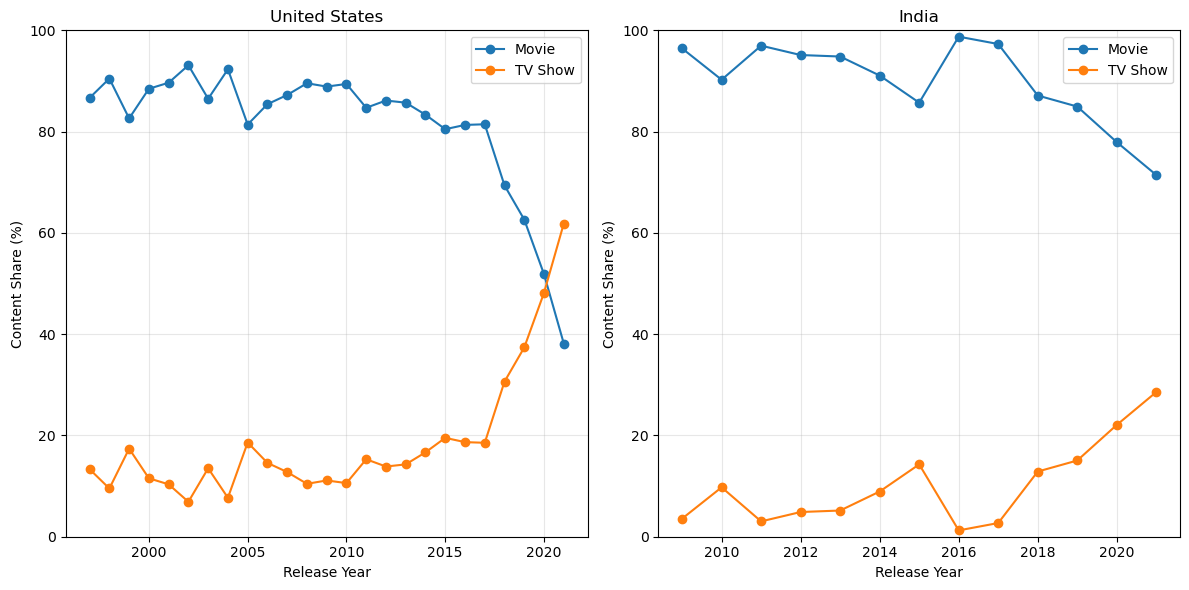

In [95]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
us=fix[fix['country']=='united states']
for x in us['type'].unique():
    data = us[us['type'] == x]
    plt.plot(
    data['release_year'],
    data['percent'],
    marker='o',
    label=x)
plt.title('United States')
plt.xlabel('Release Year')
plt.ylabel('Content Share (%)')
plt.ylim(0,100)
plt.grid(alpha=0.3)
plt.legend()


fix = fix[fix['total_titles'] >= 28]
plt.subplot(1,2,2)
ind=fix[fix['country']=='india']
for x in us['type'].unique():
    data = ind[ind['type'] == x]
    plt.plot(
    data['release_year'],
    data['percent'],
    marker='o',
    label=x)
plt.title('India')
plt.xlabel('Release Year')
plt.ylabel('Content Share (%)')
plt.ylim(0,100)
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

Business Objectives:
-
**1.Is Netflix primarily a Movie platform or a TV Show platform?**

Netflix has historically been a movie-centric platform. However, recent years show a noticeable increase in TV Show additions, indicating that the platform is gradually diversifying its content mix.

**2.Does the content mix differ across the Top 5 countries?**

In [97]:
country_type = (
    top5_df
    .groupby(['country', 'type'])['title']
    .count()
    .reset_index(name='title_count')
)

country_type_pivot = (
    country_type
    .pivot(
        index='country',
        columns='type',
        values='title_count'
    )
)

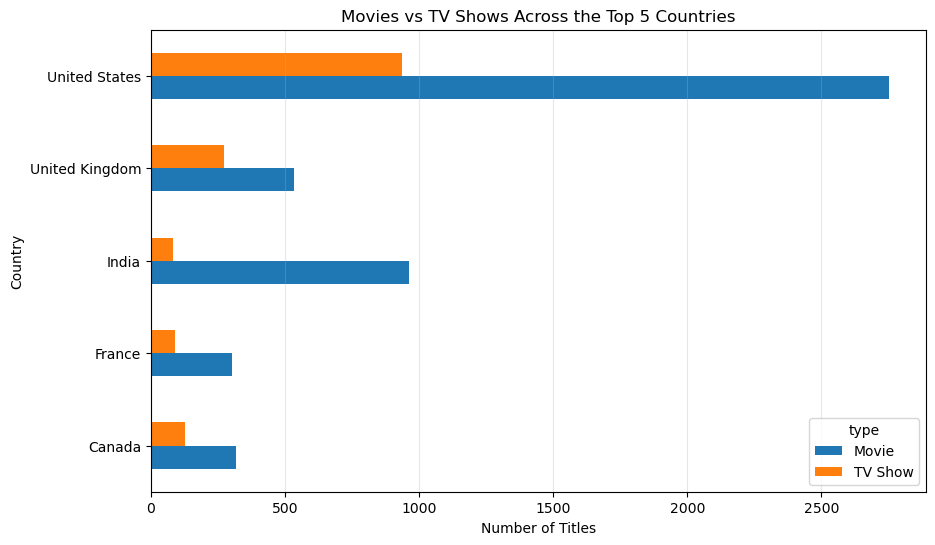

In [102]:
country_type_pivot.index = country_type_pivot.index.str.title()
country_type_pivot.plot(
    kind='barh',
    figsize=(10,6)
)

plt.title('Movies vs TV Shows Across the Top 5 Countries')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.grid(axis='x', alpha=0.3)

plt.show()

Movies dominate the Netflix catalog across all Top 5 countries. However, the balance between Movies and TV Shows differs by country, with the United States and the United Kingdom having relatively larger TV Show catalogs, while India remains heavily movie-focused.

**3.Are rapidly growing countries driving growth through Movies or TV Shows?**

The answer depends on the country. Rapidly growing countries are not expanding through the same type of content.

United States: Recent catalog growth is increasingly driven by TV Shows, with TV Shows surpassing Movies in content share by 2021.
India: Despite strong catalog growth, expansion continues to be driven primarily by Movies, with TV Shows remaining a much smaller share.

Conclusion: Rapid growth is not universally driven by either Movies or TV Shows. Instead, Netflix's content expansion varies by market, indicating region-specific growth strategies.

**4.What strategic implications does this have for Netflix's future content portfolio?**

The analysis suggests that Netflix should continue following a localized content strategy rather than adopting a single global approach.

Increase investment in TV Shows in markets where serialized content is becoming more prominent (such as the United States).
Continue investing in Movies in markets where films remain the dominant content format (such as India).
Regularly monitor changes in content mix to adapt investment decisions as audience preferences evolve across regions.

Overall implication: Rather than maintaining the same Movie-to-TV Show ratio worldwide, Netflix should optimize its content portfolio based on regional market trends and demand.

## Observation

Rapidly growing countries do not exhibit the same content growth pattern. The United States shows a clear shift toward TV Shows in recent years, whereas India's catalog growth continues to be driven primarily by Movies. This indicates that Netflix's content expansion strategy varies across major markets.

---

## Business Insight

The differing growth patterns suggest that Netflix adapts its content portfolio to regional market trends rather than following a single global strategy. Markets with increasing demand for serialized content appear to receive greater investment in TV Shows, while movie-centric markets continue to expand primarily through films.

---

## Recommendation

Based on the available catalog data, management should continue tailoring investments in Movies and TV Shows according to regional content trends instead of maintaining a uniform global content mix. Regularly monitoring changes in content composition can help align future content investments with evolving audience preferences.

---

## Limitation

This analysis is based solely on changes in the Netflix catalog over time. Since the dataset does not include viewership, watch time, subscriber growth, production costs, or revenue, it cannot determine whether Movies or TV Shows generated greater business value in these markets.

---

## Confidence Level

**Medium**

The catalog data clearly shows that rapidly growing countries follow different content growth patterns. However, the absence of audience engagement and financial metrics limits confidence in assessing the business impact of these trends.

Business Question:
-
***4.Evaluate Netflix's audience and genre portfolio to determine whether the catalog is balanced or overly dependent on specific audience segments or genres.***

In [184]:
ldf=df.copy()
ldf['listed_in']=ldf['listed_in'].str.split(',')
ldf=ldf.explode('listed_in')
ldf['listed_in']=ldf['listed_in'].str.strip().str.lower()

In [185]:
ldf['rating'].isna().sum()

np.int64(6)

## Additional Data Quality Issues

1. **Missing Ratings**
   - A small number of records have missing values in the `rating` column.
   - Since these records cannot contribute to audience rating analysis, they will be removed.

2. **Invalid Rating Values**
   - A few records contain movie durations (e.g., `74 min`, `84 min`, `66 min`) in the `rating` column instead of valid audience ratings.
   - These are data quality issues and will be excluded from the rating analysis.

3. **Generic Categories in `listed_in`**
   - The `listed_in` column contains the values `Movies` and `TV Shows`.
   - These represent content types rather than actual genres and may distort genre concentration analysis.
   - Therefore, these generic categories will be removed before analyzing genre distribution.

In [198]:
ldf= ldf.dropna(subset=['rating'])
wrong_ratings = ['74 min', '84 min', '66 min']
ldf = ldf[~ldf['rating'].isin(wrong_ratings)]
wrong_listed=['movies','tv shows']
ldf = ldf[~ldf['listed_in'].isin(wrong_listed)]

Business Objectives
-

**1.Which audience ratings dominate Netflix's catalog?**

In [201]:
ldf['rating'].value_counts().head()

rating
TV-MA    7292
TV-14    5235
TV-PG    1901
R        1580
PG-13     998
Name: count, dtype: int64

**2.Which genres dominate Netflix's catalog?**

In [202]:
ldf['listed_in'].value_counts().head()

listed_in
international movies      2752
dramas                    2426
comedies                  1674
international tv shows    1350
documentaries              869
Name: count, dtype: int64

**3.Is Netflix overly dependent on only a few genres?**

In [203]:
g=(ldf['listed_in'].value_counts(normalize=True)*100).head()
g

listed_in
international movies      14.299818
dramas                    12.605872
comedies                   8.698363
international tv shows     7.014809
documentaries              4.515459
Name: proportion, dtype: float64

In [204]:
g.sum()

np.float64(47.13432060275396)

**HHI (Herfindahl–Hirschman Index):** A statistical measure used to quantify the concentration of data

- A value closer to **0** indicates a **well-diversified** data
- A value closer to **1** indicates a **highly concentrated** data

In [206]:
l=ldf['listed_in'].value_counts(normalize=True)
HHI=(l**2).sum()
HHI

np.float64(0.06404684882368653)

**Observation:** The Top 5 genres account for approximately 47% of all genre assignments, while the remaining 53% is distributed across many other genres. The calculated HHI of 0.06 indicates that Netflix's genre portfolio is relatively diversified rather than highly concentrated.

**4.Do dominant audience ratings align with dominant genres?**

In [215]:
rating_genre = (
    ldf.groupby(['rating', 'listed_in'])
    .size()
    .reset_index(name='title_count')
)

rating_genre.sort_values('title_count',ascending=False).head(20)

,rating,listed_in,title_count
182,TV-MA,international movies,1130
111,TV-14,international movies,1065
178,TV-MA,dramas,830
183,TV-MA,international tv shows,714
107,TV-14,dramas,693
112,TV-14,international tv shows,472
102,TV-14,comedies,465
200,TV-MA,tv dramas,434
173,TV-MA,comedies,431
80,R,dramas,375


In [210]:
rating_genre_pivot =rating_genre.pivot(
        index='rating',
        columns='listed_in',
        values='title_count'
).fillna(0)

rating_genre_pivot

listed_in,action & adventure,anime features,anime series,british tv shows,children & family movies,classic & cult tv,classic movies,comedies,crime tv shows,cult movies,...,stand-up comedy & talk shows,teen tv shows,thrillers,tv action & adventure,tv comedies,tv dramas,tv horror,tv mysteries,tv sci-fi & fantasy,tv thrillers
rating,,,,,,,,,,,,,,,,,,,,,
G,1.0,0.0,0.0,0.0,33.0,0.0,8.0,11.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NC-17,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NR,9.0,0.0,0.0,2.0,0.0,0.0,3.0,14.0,1.0,3.0,...,1.0,0.0,4.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0
PG,32.0,5.0,0.0,0.0,195.0,0.0,17.0,148.0,0.0,4.0,...,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
PG-13,148.0,4.0,0.0,0.0,11.0,0.0,10.0,168.0,0.0,13.0,...,0.0,0.0,54.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
R,220.0,0.0,0.0,0.0,0.0,0.0,32.0,180.0,0.0,37.0,...,0.0,0.0,153.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
TV-14,213.0,23.0,71.0,46.0,18.0,10.0,23.0,465.0,111.0,7.0,...,10.0,32.0,119.0,44.0,140.0,269.0,17.0,31.0,41.0,11.0
TV-G,0.0,1.0,0.0,17.0,51.0,1.0,1.0,29.0,1.0,0.0,...,2.0,2.0,0.0,1.0,28.0,9.0,0.0,1.0,1.0,1.0
TV-MA,201.0,15.0,59.0,108.0,1.0,9.0,11.0,431.0,350.0,5.0,...,38.0,20.0,240.0,90.0,269.0,434.0,57.0,65.0,21.0,39.0


In [213]:
top10_genres = ldf['listed_in'].value_counts().head(10).index
top10_genres
rating_genre_pivot = rating_genre_pivot[top10_genres]

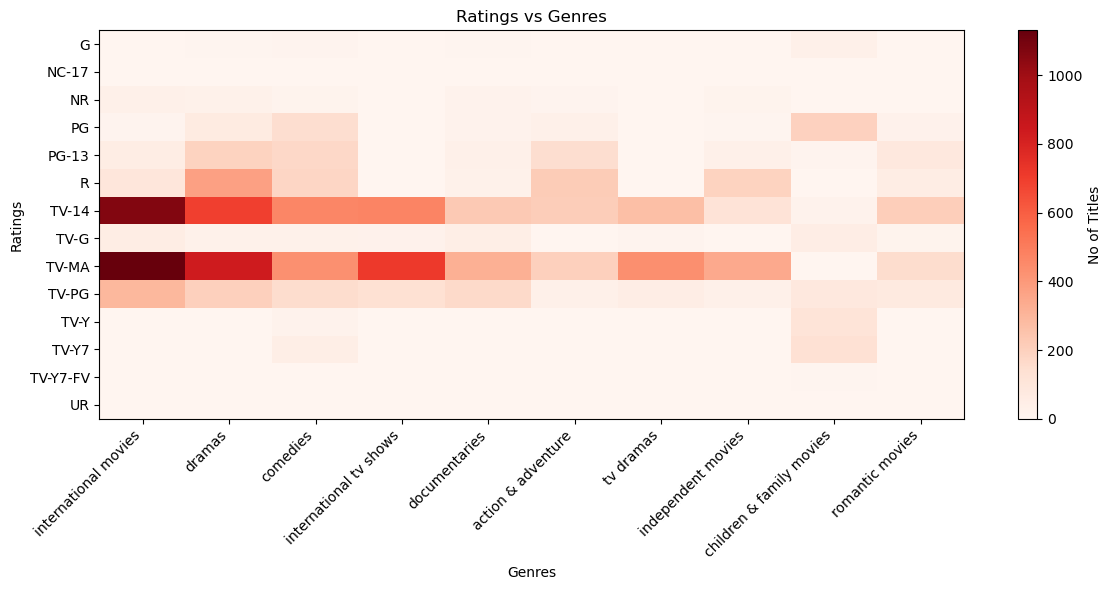

In [226]:
plt.figure(figsize=(12,6))
plt.imshow(rating_genre_pivot, aspect='auto',cmap='Reds')
plt.colorbar(label='No of Titles')
plt.xticks(
    range(len(rating_genre_pivot.columns)),
    rating_genre_pivot.columns,
    rotation=45,
    ha='right')
plt.yticks(
    range(len(rating_genre_pivot.index)),
    rating_genre_pivot.index)
plt.title("Ratings vs Genres")
plt.xlabel("Genres")
plt.ylabel("Ratings")

plt.tight_layout()
plt.show()

### Observation

The heatmap shows a strong relationship between Netflix's dominant audience ratings and its dominant genres.

- **TV-MA** has the highest concentration of titles across most of the leading genres, particularly **International Movies**, **Dramas**, **International TV Shows**, and **TV Dramas**.
- **TV-14** also contributes significantly to these same genres, although at lower volumes than TV-MA.
- Family-oriented ratings such as **TV-Y**, **TV-Y7**, **TV-G**, and **G** are primarily concentrated in **Children & Family Movies** and have relatively few titles in the dominant genres.
- Mature ratings (**TV-MA** and **TV-14**) account for the majority of Netflix's most popular genres.


**5.Strategic Recommendation based on the current catalog**

### Recommendation

Based on the current catalog, Netflix does not appear to be overly dependent on a small number of genres, as the portfolio remains relatively diversified (HHI = 0.06). However, the catalog is heavily concentrated in mature audience ratings (TV-MA and TV-14), which are primarily associated with International Movies, Dramas, and International TV Shows.

Rather than making immediate content production decisions, management should investigate:

- Whether the current dominance of mature-rated content reflects actual viewer demand across different audience segments.
- Whether family- and youth-oriented content is underrepresented relative to audience preferences.
- Whether rapidly growing international markets require different genre or audience-rating mixes.
- Whether the current genre distribution continues to maximize viewer engagement despite the diversified portfolio.

These investigations should be supported using viewing hours, completion rates, regional consumption patterns, subscriber demographics, and customer engagement metrics, which are not available in the current dataset.

## Observation

- Netflix's catalog is geographically diverse, although the United States contributes the largest share of titles.
- The Top 5 genres account for approximately **47%** of all genre assignments, while the remaining genres are broadly distributed (HHI = **0.06**), indicating a diversified portfolio.
- **TV-MA** and **TV-14** are the dominant audience ratings and are strongly associated with major genres such as **International Movies**, **Dramas**, and **International TV Shows**.

---

## Business Insight

Netflix's catalog appears well diversified from a genre perspective, reducing the risk of overdependence on a small set of genres. However, the catalog is more concentrated around mature audience ratings, suggesting that a significant portion of the content targets adult viewers.

---

## Recommendation

Management should investigate whether the current dominance of mature-rated content reflects actual viewer demand across different regions and audience segments. It would also be valuable to assess whether family-oriented and younger audience content is sufficiently represented based on engagement and viewing behavior before making future portfolio decisions.

---

## Limitation

This analysis is based only on Netflix's catalog metadata. It does not include viewer engagement, watch hours, completion rates, subscriber demographics, regional demand, or content production costs. Therefore, recommendations are limited to catalog composition rather than content performance.

---

## Confidence Level

**High**

The conclusions are supported by consistent findings across country distribution, genre concentration (HHI), audience ratings, and genre-rating relationships. However, additional user engagement data would strengthen strategic recommendations.

---

## Additional Data Requested

To make stronger business recommendations, I would request **viewership and engagement data**, including watch hours, completion rates, regional viewing trends, and audience demographics. This would help determine whether the current catalog composition aligns with actual viewer preferences rather than just the number of titles available.

# Final Executive Conclusion

This project analyzed Netflix's global content catalog to generate data-driven business insights. The analysis covered data quality assessment, geographic distribution, content growth trends, genre concentration, audience ratings, and the relationship between audience ratings and genres.

The findings show that Netflix's catalog has a strong global presence, with the **United States** contributing the largest share of titles, while countries such as **India** and the **United Kingdom** have experienced notable growth in recent years. Although **Movies** continue to dominate the catalog, recent growth in some markets suggests an increasing contribution from **TV Shows**, indicating that content expansion strategies are evolving across regions.

From a portfolio perspective, Netflix does not appear to be overly dependent on a small number of genres. The Top 5 genres account for approximately **47%** of all genre assignments, and the calculated **HHI of 0.06** indicates a well-diversified genre portfolio. However, the audience rating analysis reveals that the catalog is largely concentrated around **TV-MA** and **TV-14**, with these ratings strongly aligned with dominant genres such as **International Movies**, **Dramas**, and **International TV Shows**.

While these findings provide valuable insight into the composition of Netflix's catalog, they should not be interpreted as direct indicators of business performance. The dataset does not include key business metrics such as watch hours, viewer engagement, subscriber demographics, production costs, licensing expenses, or content profitability. As a result, the recommendations made throughout this analysis should be viewed as **strategic hypotheses** that require validation using operational and performance data.

Overall, this project demonstrates how effective data cleaning, exploratory analysis, visualization, and business-focused interpretation can transform raw catalog data into meaningful strategic insights. The analysis provides a solid foundation for further investigation while highlighting the importance of combining catalog analytics with viewer engagement and financial data before making long-term portfolio decisions.

# Key Takeaways

- **Business decisions should be driven by data rather than assumptions.** Throughout the analysis, every conclusion was supported by quantitative evidence instead of intuition.

- **Data quality directly impacts the reliability of insights.** Identifying and handling missing values, invalid ratings, and generic genre categories helped ensure more accurate analysis.

- **Different business questions require different analytical techniques.** Trend analysis, concentration metrics (HHI), visualizations, and cross-tab analysis each provided unique insights into Netflix's content portfolio.

- **A diversified catalog does not necessarily imply a balanced audience strategy.** While Netflix's genre portfolio is well diversified, the catalog is heavily concentrated around mature audience ratings (TV-MA and TV-14).

- **Business recommendations should acknowledge data limitations.** Without engagement metrics such as watch hours, viewer demographics, and content profitability, recommendations should be treated as strategic hypotheses rather than definitive decisions.